# Conceptos básicos de estadística

## 📌 Tema 1: ¿Qué es la estadística?

La estadística es el campo de estudio y la práctica de recopilar, organizar, analizar, interpretar y presentar datos para extraer conclusiones o tomar decisiones.

## 📌 Tema 2: Tipo de estadística

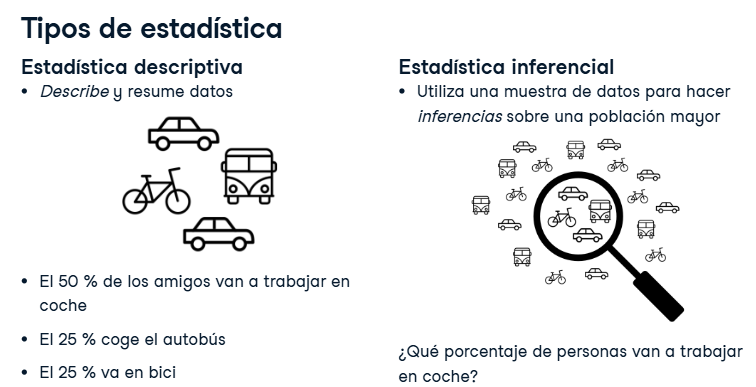

## 📌 Tema 3:  Clasificación de los tipos de datos

La estadística puede utilizarse para responder muchos tipos de preguntas, pero saber
identificar qué tipo de dato se tiene es esencial para sacar conclusiones correctas
y elegir los gráficos adecuados.

- Numéricos (Cuantitativos): Miden
  - Continuos: pueden tomar cualquier decimal dentro de un rango, como la velocidad
    o la temperatura.
  - Discretos: son valores enteros y contables, como la cantidad de mascotas
    que tiene una persona, la cantidad de hijos, entre otros.

- Categóricos (Cualitativos): Describen
  - Nominales: no tienen un orden inherente, como el estado civil o el color
    de ojos, país.
  - Ordinales: sí tienen un orden inherente, como el nivel de satisfacción en
    una encuesta (bajo, medio, alto), nivel educativo.

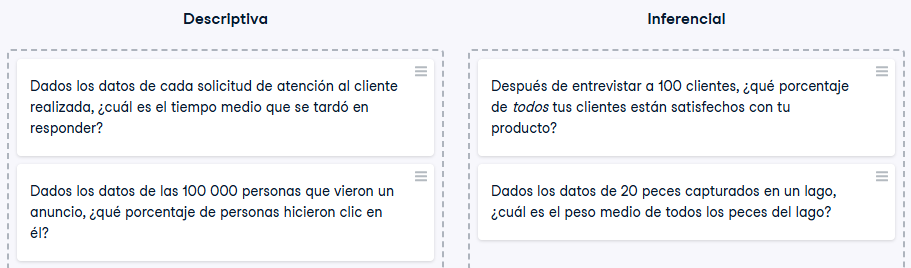

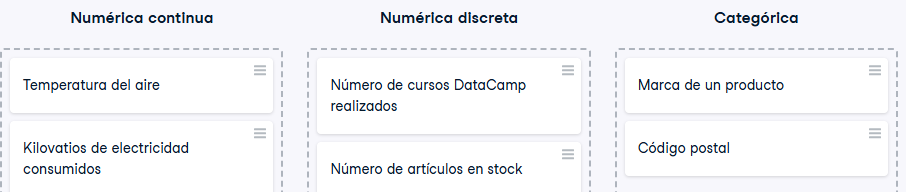

### Medidas de dispersión:

¿Qué es la dispersión?
- Imagina que tienes dos equipos de baloncesto. Ambos equipos tienen una media de altura de 1.80 metros. A primera vista, parecen iguales, ¿verdad? Pero resulta que en el equipo A todos miden exactamente 1.80 metros, mientras que en el equipo B hay jugadores de 1.50, 1.80 y 2.10 metros. Aunque el promedio sea el mismo, las alturas de los jugadores del equipo B están mucho más separadas o dispersas.

- La dispersión es precisamente eso: una medida que nos dice qué tan cerca o lejos están los puntos de datos entre sí. Si los datos están muy juntos, la dispersión es baja; si están muy separados, la dispersión es alta.

- La difusión describe que tan separados o cercanos están los puntos de datos.

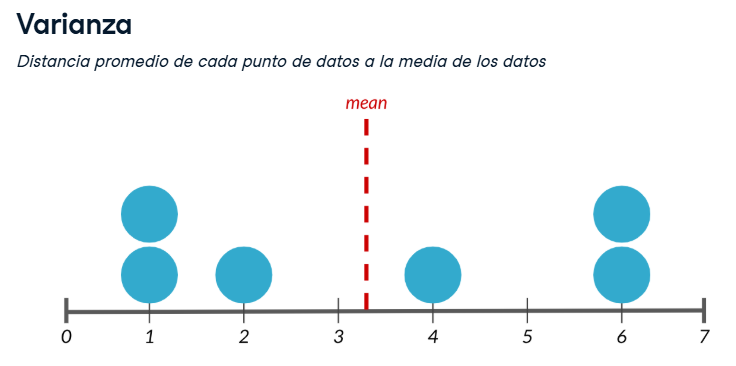

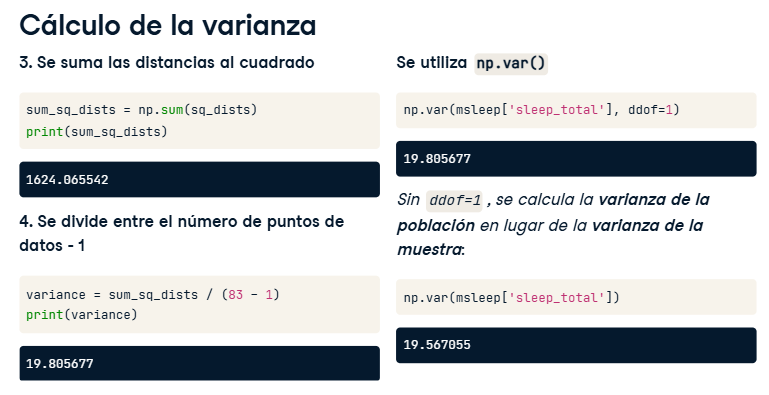

- La desviación estándar es simplemente la raíz cuadrada de la varianza. ¡Así de sencillo! Nos devuelve las unidades a su estado original (por ejemplo, "horas"), lo que nos permite entender la dispersión de forma más clara.

- Rango intercuartílico (IQR): IQR es una medida de dispersión que no se ve tan afectada por los valores extremos o "atípicos". Para entenderlo, primero necesitamos saber qué es la distancia entre el tercer cuartil (Q3) y el primer cuartil (Q1). Es la altura de la caja en un diagrama de caja. Esta medida es muy útil porque se enfoca en el 50% central de los datos, ignorando los extremos.

¿Qué son los valores atípicos?
- valores atípicos son puntos de datos que se alejan demasiado del resto de la información. Son como ese jugador de baloncesto de 2.10 metros en un equipo de jugadores de 1.80 metros. Para identificarlos, una regla común es buscar cualquier punto que sea:

Varianza y desviación típica

- La varianza y la desviación típica son dos de las formas más habituales de medir la dispersión de una variable, y en este ejercicio practicarás su cálculo. La dispersión es importante, ya que puede ayudar a definir las expectativas. Por ejemplo, si un vendedor vende una media de 20 productos al día pero tiene una desviación típica de 10 productos, probablemente habrá días en los que venda 40 productos, pero también días en los que solo venda uno o dos. Este tipo de información es importante, sobre todo a la hora de hacer predicciones.

In [ ]:
# Print variance and sd of co2_emission for each food_category
print(food_consumption.groupby('food_category')['co2_emission'].agg([np.var, np.std]))

# Create histogram of co2_emission for food_category 'beef'
food_consumption[food_consumption['food_category']=='beef']['co2_emission'].hist()
plt.show()

# Create histogram of co2_emission for food_category 'eggs'
plt.figure()
food_consumption[food_consumption['food_category']=='eggs']['co2_emission'].hist()
plt.show()

Cuartiles, cuantiles y quintiles
- Los cuantiles son una forma estupenda de resumir datos numéricos, ya que pueden utilizarse para medir la tendencia central y la dispersión, así como para hacerse una idea de dónde se sitúa un punto de datos en relación con el resto del conjunto de datos. Por ejemplo, puedes querer ofrecer un descuento al 10 % de los usuarios más activos de un sitio web.

### Encontrar valores atípicos mediante IQR


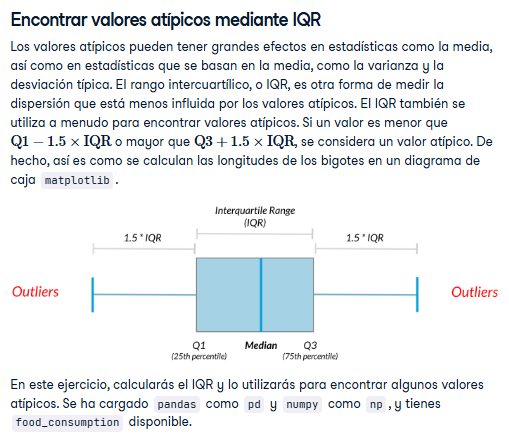

In [ ]:
# Calculate total co2_emission per country: emissions_by_country
emissions_by_country = food_consumption.groupby('country')['co2_emission'].sum()

# Compute the first and third quantiles and IQR of emissions_by_country
q1 = np.quantile(emissions_by_country, 0.25)
q3 = np.quantile(emissions_by_country, 0.75)
iqr = q3 - q1

# Calculate the lower and upper cutoffs for outliers
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# Subset emissions_by_country to find outliers
outliers = emissions_by_country[(emissions_by_country < lower) | (emissions_by_country > upper)]
print(outliers)

- Parece que Argentina tiene una cantidad sustancialmente mayor de emisiones de CO2 por persona que otros países del mundo

## 📌 Tema 4: Población, muestra y muestreo

- Población: Representa todos los elementos puede ser personas, datos que vas a estudiar. Por ejemplo, todos los ciudadanos de Perú.
- Muestra: Es el subconjuento parte de la población, se aplica una regla que debe ser representativa y aleatoria sin preferencias ni sesgos.
- Muestreo: Es el metodo que se utiliza para seleccionar a los integrantes de una muestra.

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [40]:
PATH = "/content/drive/MyDrive/machine_learning/estadistica/"
PATH_CALIFORNIA = "/content/drive/MyDrive/machine_learning/california_housing/"
df_food_consumption = pd.read_csv(f"{PATH}food_consumption.csv")
df_california_housing = pd.read_csv(f"{PATH_CALIFORNIA}housing.csv")
df_food_consumption.head()

,Unnamed: 0,country,food_category,consumption,co2_emission
0,1,Argentina,pork,10.51,37.20
1,2,Argentina,poultry,38.66,41.53
2,3,Argentina,beef,55.48,1712.00
3,4,Argentina,lamb_goat,1.56,54.63
4,5,Argentina,fish,4.36,6.96


### Relacionado conceptos

Dataset: Consumo de alimentos que tienen mayor emiciones de CO2
- Población: Todos los paises del mundo.
- Muestra: Por ejemplo solamente analizaremos a argentina
- Variables:
  - Cualitativas: country, food_category
  - Cuantitativas: consumption, co2_emission

## 📌 Tema 5: Medidas de tendencia central

Se busca representar el punto central de los datos.

Hay 3 formas:
- La media: El promedio es la sumatoria de todos los número entre la cantidad de esos número, sirve para rellenar datos faltantes en datos cuantitativos y entre otras cosas que veremos más adelante. Teniendo cuidado con los valores atípicos.

$$\mu = \frac{\sum_{i=1}^{n} x_i}{n}$$

In [20]:
print(df_food_consumption['consumption'].sum()/len(df_food_consumption['consumption']))

print(df_food_consumption['consumption'].mean())

28.1104055944056
28.1104055944056


- Mediana: Igual es para datos cuantitativos, además los datos deben estar ordenados de menor a mayor. Tambien ayuda a rellenar datos vacios pero con un beneficio no se deja influenciar por los datos exajerados (valores atípicos)
$$\text{Posición} = \frac{n + 1}{2}$$

In [23]:
estaturas = [160, 185, 170, 155, 162]
df_estaturas = pd.Series(estaturas)
mediana = df_estaturas.median()
print(f'Las estaturas son: {estaturas}')
print(f'La mediana es: {mediana}')

Las estaturas son: [160, 185, 170, 155, 162]
La mediana es: 162.0


- Moda: Ya el último que queda si es para datos cualitativos nos importa solamente quien es el más popular.

In [27]:
lista_comidas = ['beef', 'poultry', 'beef', 'fish', 'beef', 'pork']
df_comidas = pd.Series(lista_comidas)
moda_comida = df_comidas.mode()[0]
print("La moda de alimentos es:", moda_comida)

La moda de alimentos es: beef


### El sesgo

Cuando gráficas tus datos en un histograma, la forma no siempre es perfecto. El sesgo te dice hacia donde se estira la cola de la gráfica.

- Sesgo a la derecha (Asimetría Positiva): La montaña está a la izquierda (números pequeños) y la cola larga se estira hacia la derecha (números grandes) se prioriza la mediana.
- Sesgo a la izquierda (Asimetría Negativa): La montaña está a la derecha (números grandes) y la cola larga se estira hacia la izquierda (números pequeños) se prioriza la mediana.
- Distribución Simétrica (Campana de Gauss): La montaña está perfectamente en el centro. Las dos colas son iguales. Se prioriza la media.

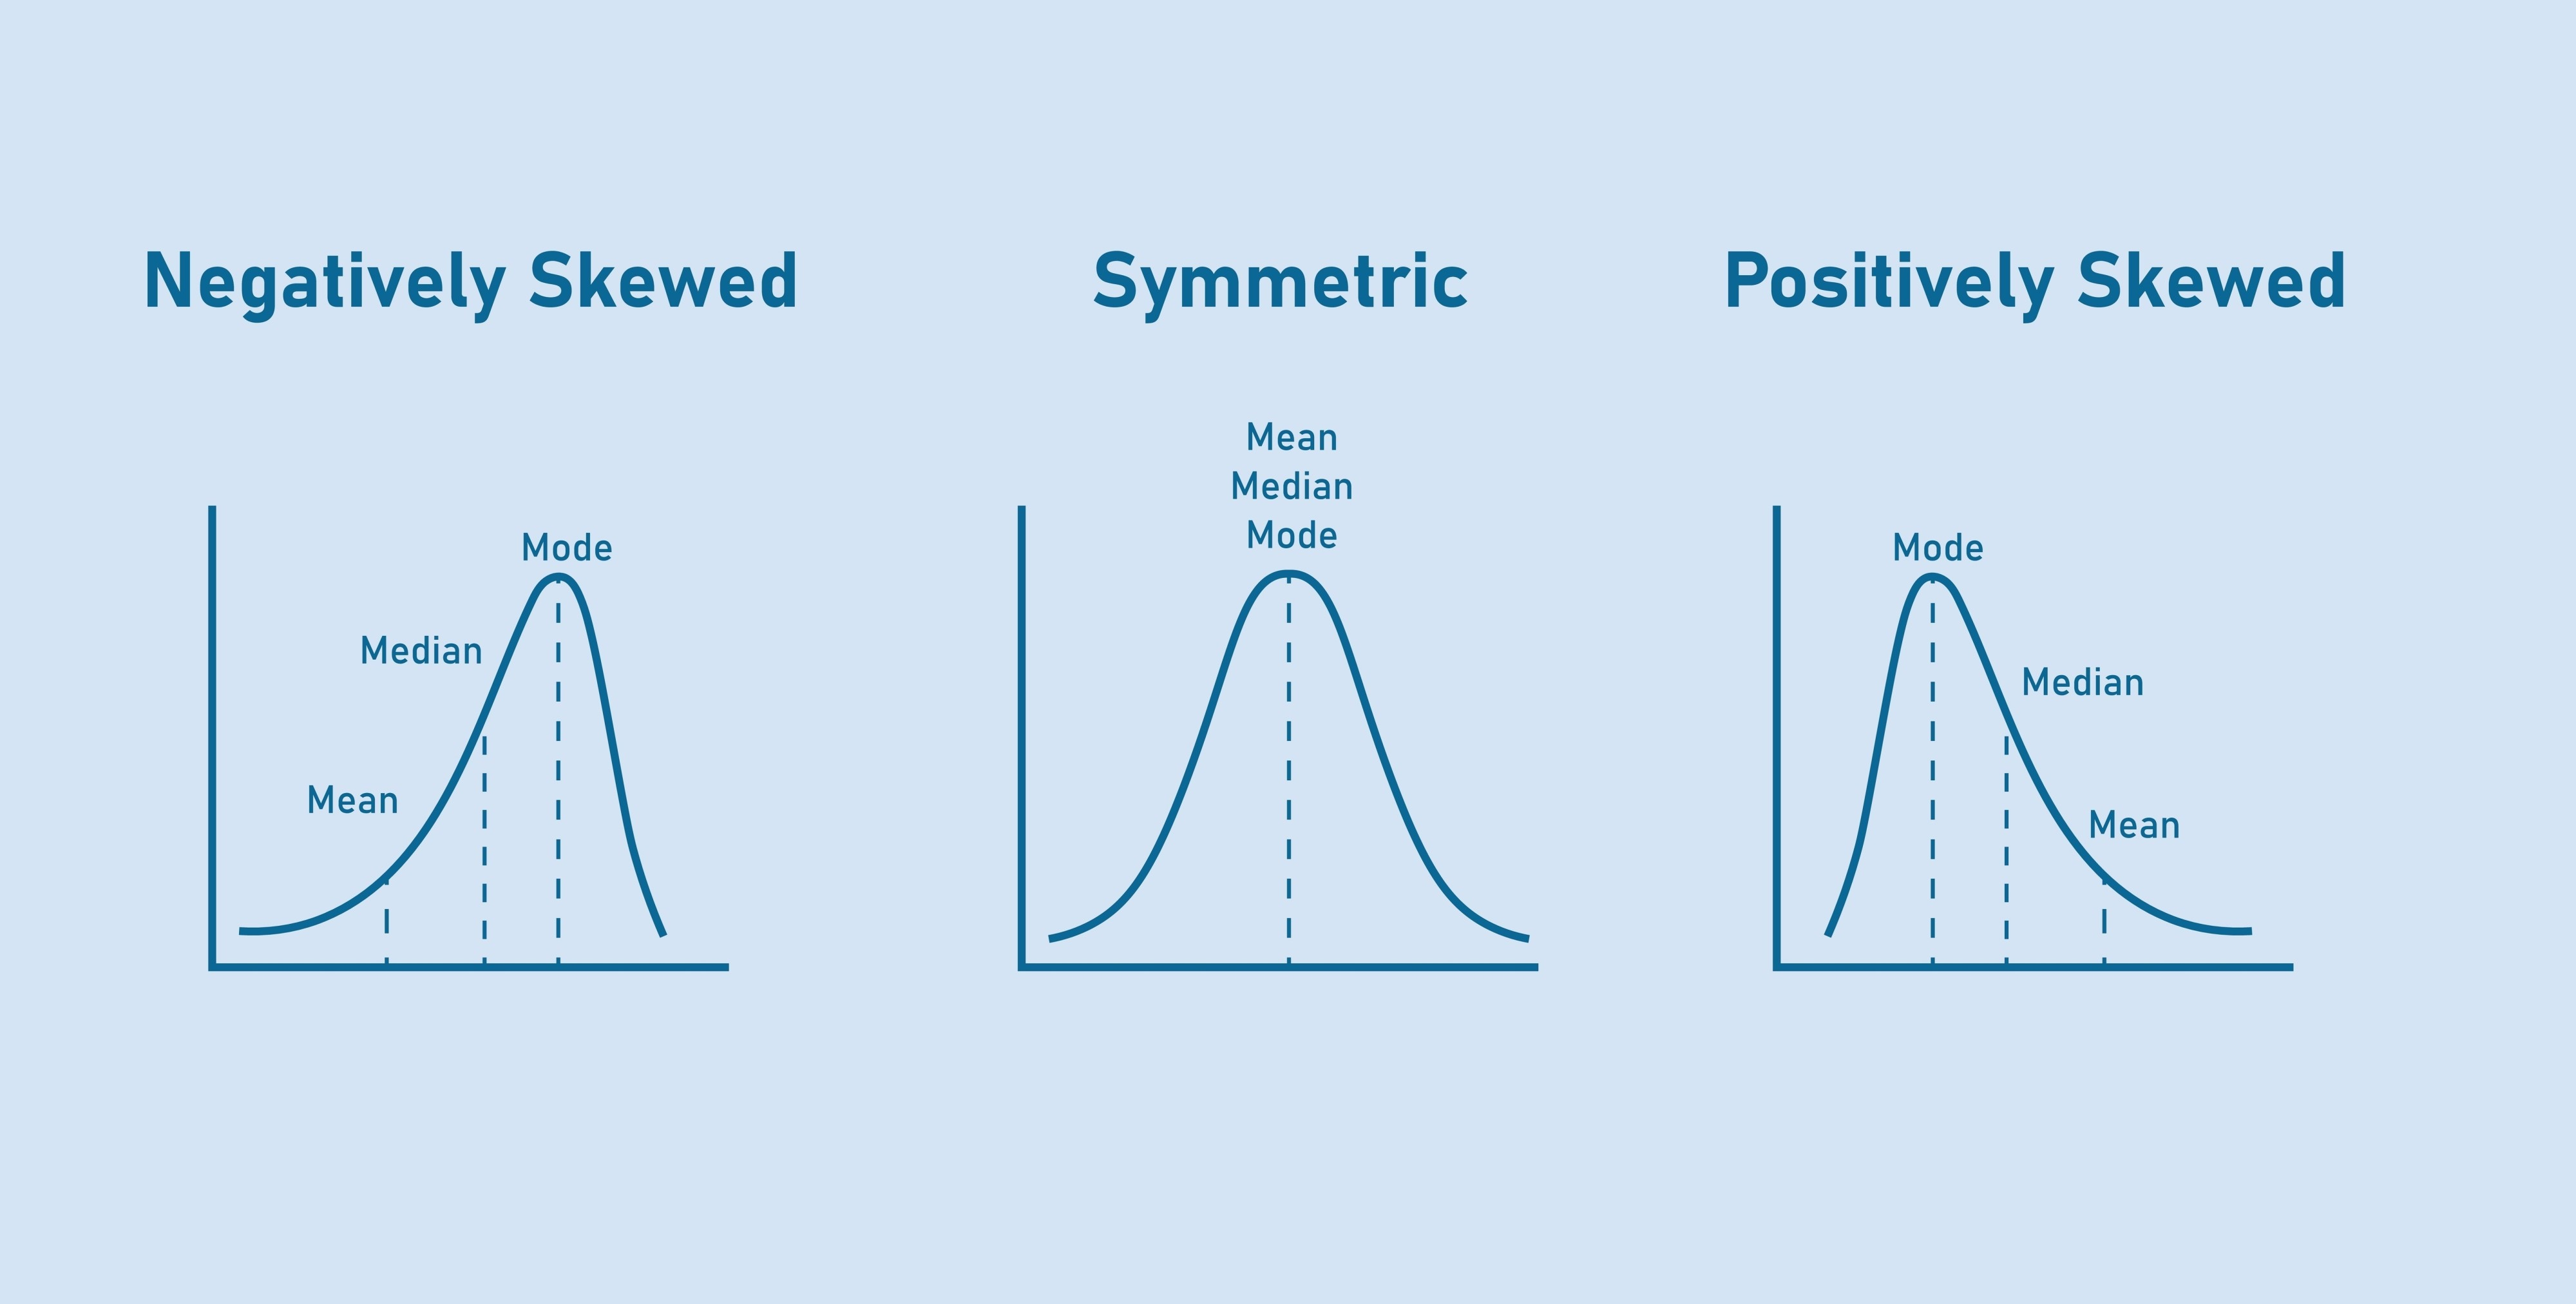

In [29]:
# Filtramos por arroz
rice_consumption = df_food_consumption[df_food_consumption["food_category"] == 'rice']

# Ordenamos de menor a mayor por emisión de CO2 y mostramos los primeros 5
print("--- Países con las EMISIONES MÁS BAJAS en arroz ---")
print(rice_consumption[['country', 'co2_emission']].sort_values(by='co2_emission').head())

# Si quieres ver los más altos (los que estiran la cola a la derecha) cambias a .tail()
print("\n--- Países con las EMISIONES MÁS ALTAS (Datos atípicos) ---")
print(rice_consumption[['country', 'co2_emission']].sort_values(by='co2_emission').tail())

--- Países con las EMISIONES MÁS BAJAS en arroz ---
                    country  co2_emission
767                  Poland          1.22
833                 Tunisia          1.37
877                 Morocco          1.41
657                  Serbia          1.56
734  Bosnia and Herzegovina          2.41

--- Países con las EMISIONES MÁS ALTAS (Datos atípicos) ---
         country  co2_emission
1196     Myanmar        169.94
1405   Indonesia        172.27
1174     Vietnam        184.99
1372    Cambodia        203.60
1427  Bangladesh        219.76


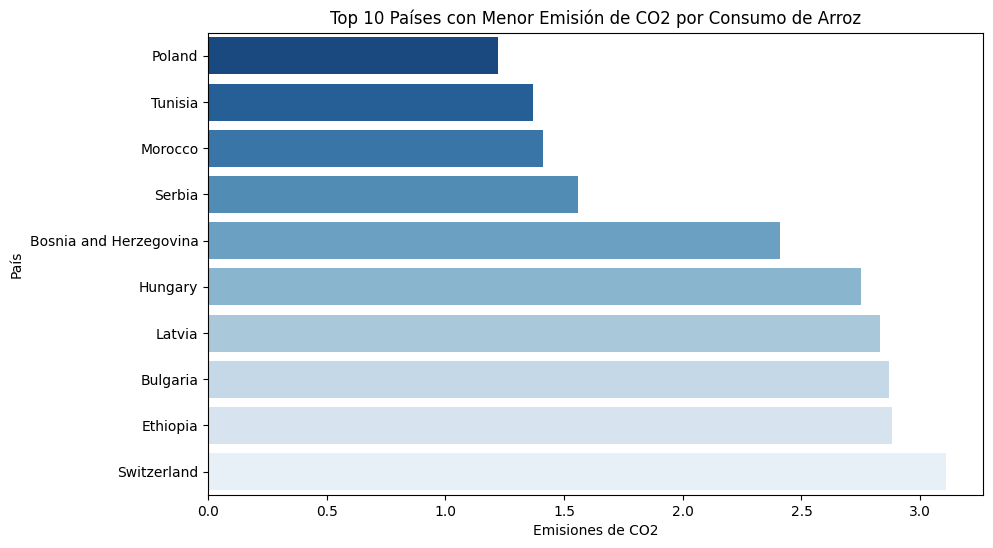

In [34]:
rice_consumption = df_food_consumption[df_food_consumption["food_category"] == 'rice']

# Ordenamos los datos para que el gráfico sea fácil de leer
rice_ordenado = rice_consumption.sort_values(by='co2_emission')
# Hacemos un gráfico de barras (si son muchos países, tomamos los 10 más bajos)
plt.figure(figsize=(10, 6))
sns.barplot(x='co2_emission', y='country', data=rice_ordenado.head(10), palette='Blues_r')

plt.title('Top 10 Países con Menor Emisión de CO2 por Consumo de Arroz')
plt.xlabel('Emisiones de CO2')
plt.ylabel('País')
plt.show()

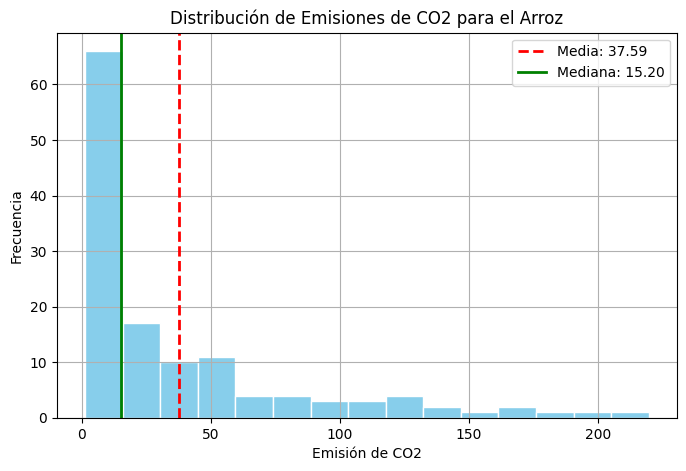

In [33]:
# 1. Filtrar los datos (tu paso inicial)
rice_consumption = df_food_consumption[df_food_consumption["food_category"] == 'rice']

# 2. Calcular la media y la mediana de las emisiones de CO2
media = rice_consumption["co2_emission"].mean()
mediana = rice_consumption["co2_emission"].median()

# 3. Crear el gráfico
plt.figure(figsize=(8, 5))
rice_consumption["co2_emission"].hist(bins=15, color='skyblue', edgecolor='white')

# 4. Agregar las líneas verticales para la media y la mediana
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')

# 5. Personalizar el gráfico
plt.title('Distribución de Emisiones de CO2 para el Arroz')
plt.xlabel('Emisión de CO2')
plt.ylabel('Frecuencia')
plt.legend()  # Esto es clave para que se muestren las etiquetas de las líneas

# 6. Mostrar el resultado
plt.show()

## 📌 Tema 6: Percentiles

El percentil es un número que te dice qué porcentaje de los datos se quedó por debajo de ti. Se ordena de menor a mayor.

| Cuartil | Percentil | Significado |
|---|---|---|
| Q1 | P25 | 25% de datos por debajo |
| Q2 | P50 | 50% = Mediana |
| Q3 | P75 | 75% de datos por debajo |

**Sesgo de Fisher:** < 0.5 pequeño | [0.5,1) moderado | ≥ 1 grande  
**Curtosis:** = 0 normal | > 0 picuda (leptocúrtica) | < 0 achatada (platicúrtica)

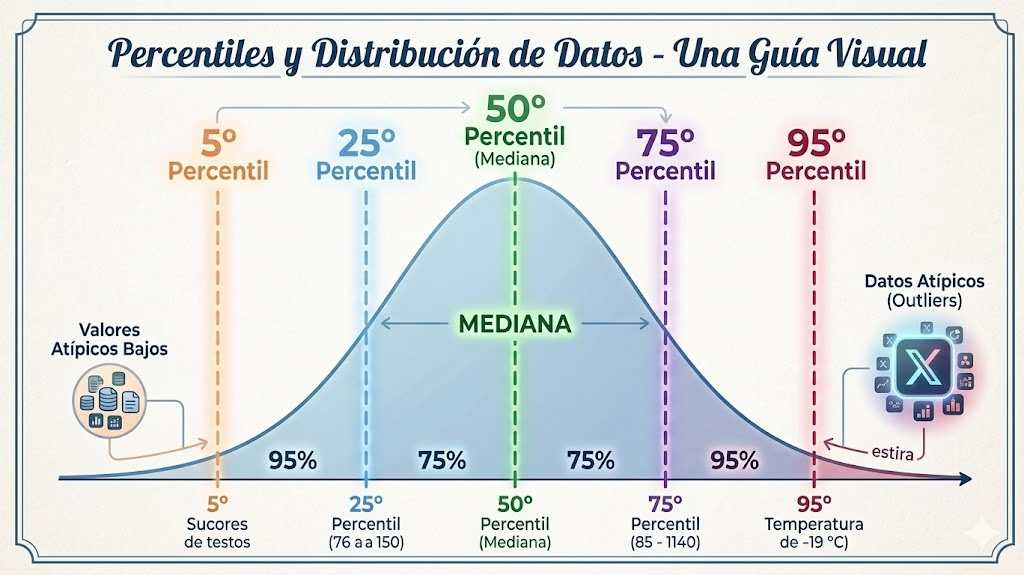

In [36]:
df_food_consumption.describe()

,Unnamed: 0,consumption,co2_emission
count,1430.000000,1430.000000,1430.000000
mean,715.500000,28.110406,74.383993
std,412.949755,49.818044,152.098566
min,1.000000,0.000000,0.000000
25%,358.250000,2.365000,5.210000
50%,715.500000,8.890000,16.530000
75%,1072.750000,28.132500,62.597500
max,1430.000000,430.760000,1712.000000


Por ejemplo en emisiones de co2:
- El 25 % de emisiones de co2 valen menos que 5.21
- El 50 % es el punto central se tiene de emisiones de co2 16.53
- El 75 % de emisiones de co2 valen más que 62.59

In [41]:
df_california_housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [42]:
df_california_housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 📌 Tema 7: Desviación estandar

Indica que tan disperso están los datos respecto a la media. Una Desviación baja significa datos agrupados y una alta datos dispersos.

Utilizando Regla empirica

Formula para saber si la desviación estandar es grande o no:
- std / media

Para median_house_value como se observa en la gráfica los precios están muy dispersos.

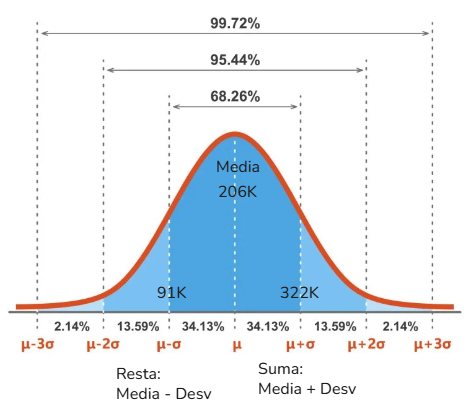

## ## 📌 Tema 8: Histogramas

Es una herramienta de visualización que nos permite observar como se distribuyen los valores en variable númericas y agrupa los valores en rangos de bins y muestra cuantas observaciones caen dentro de cada grupo.

Ayuda a identificar:
- Concentraciones
- Dispersiones y asimetrias
- Valores atípicos
- Colas largas

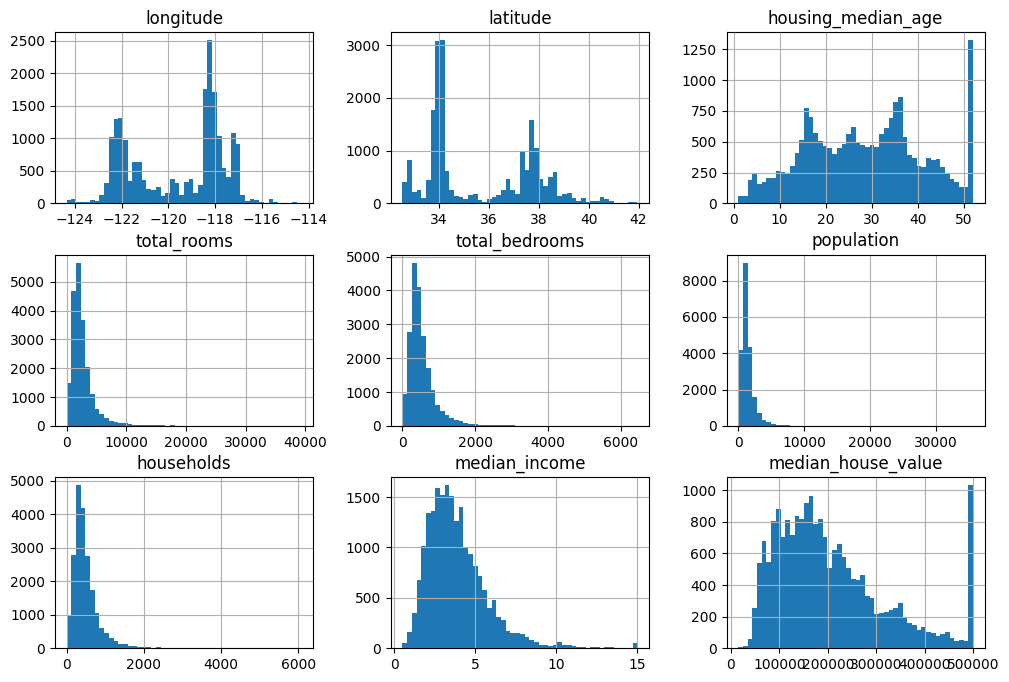

In [45]:
df_california_housing.hist(bins=50, figsize=(12, 8))
plt.show()

- El eje x: los valores
- El eje y: la cantidad de registros